# Gabarito — Paralelogramos e Casos Particulares

Este notebook traz a resolução comentada dos exercícios de [`0409a_paralelogramos_e_casos_particulares.ipynb`](0409a_paralelogramos_e_casos_particulares.ipynb).

⚠️ **Antes de olhar aqui:** tente resolver os exercícios sozinho no notebook original e use as células de verificação (`assert`) para conferir sua resposta. Volte a este gabarito só depois de tentar — ou se travar de verdade em algum passo.

In [1]:
# Imports necessários para os exercícios abaixo
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Polygon

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas do notebook principal (reconstruídas aqui).
def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Eixo no estilo Nord, sem grade e sem números, com escala igual, enquadrando os `pontos`."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice` entre P e Q."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def ponto_medio(P, Q) -> np.ndarray:
    """Ponto médio do segmento PQ: a média das coordenadas."""
    return (np.asarray(P, dtype=float) + np.asarray(Q, dtype=float)) / 2


def orientacao(O, P, Q) -> float:
    """Multiplicação cruzada com sinal: zero se colineares, positiva se O → P → Q vira à esquerda."""
    return (P[0] - O[0]) * (Q[1] - O[1]) - (P[1] - O[1]) * (Q[0] - O[0])


def area_com_sinal(vertices) -> float:
    """Área com sinal pela fórmula do cadarço (positiva no sentido anti-horário)."""
    n = len(vertices)
    return sum(orientacao((0, 0), vertices[k], vertices[(k + 1) % n]) for k in range(n)) / 2


def angulos_internos(vertices) -> list[float]:
    """Medidas (em graus) dos ângulos internos de um polígono simples, na ordem dos vértices."""
    n = len(vertices)
    sentido = 1 if area_com_sinal(vertices) > 0 else -1
    angulos = []
    for k in range(n):
        anterior, vertice, proximo = vertices[k - 1], vertices[k], vertices[(k + 1) % n]
        angulo = medir_angulo(vertice, anterior, proximo)
        if orientacao(anterior, vertice, proximo) * sentido < 0:
            angulo = 360 - angulo
        angulos.append(angulo)
    return angulos


def segmentos_se_cruzam(P1, P2, Q1, Q2) -> bool:
    """True se os segmentos P1P2 e Q1Q2 se cruzam formando um "X"."""
    return (orientacao(P1, P2, Q1) * orientacao(P1, P2, Q2) < 0
            and orientacao(Q1, Q2, P1) * orientacao(Q1, Q2, P2) < 0)


def tipo_de_quadrilatero(vertices) -> str:
    """'convexo', 'côncavo', 'cruzado' ou 'degenerado'."""
    A, B, C, D = vertices
    giros = [orientacao(vertices[k - 1], vertices[k], vertices[(k + 1) % 4]) for k in range(4)]
    if any(math.isclose(g, 0, abs_tol=1e-9) for g in giros):
        return "degenerado"
    if segmentos_se_cruzam(A, B, C, D) or segmentos_se_cruzam(B, C, D, A):
        return "cruzado"
    if all(g > 0 for g in giros) or all(g < 0 for g in giros):
        return "convexo"
    return "côncavo"


def sao_paralelos(P1, P2, Q1, Q2) -> bool:
    """True se os segmentos P1P2 e Q1Q2 têm a mesma direção (a menos de 180°)."""
    diferenca = (direcao_de(P1, P2) - direcao_de(Q1, Q2)) % 180
    return math.isclose(diferenca, 0, abs_tol=1e-6) or math.isclose(diferenca, 180, abs_tol=1e-6)


def iguais(x: float, y: float) -> bool:
    """Compara duas medidas com uma tolerância pequena."""
    return math.isclose(x, y, rel_tol=1e-9, abs_tol=1e-6)


def classificar_quadrilatero(A, B, C, D) -> list[str]:
    """Todas as categorias da hierarquia às quais o quadrilátero ABCD pertence (convenção inclusiva)."""
    if tipo_de_quadrilatero([A, B, C, D]) in ("cruzado", "degenerado"):
        return []
    categorias = ["quadrilátero"]
    pares_paralelos = int(sao_paralelos(A, B, D, C)) + int(sao_paralelos(B, C, A, D))
    if pares_paralelos >= 1:
        categorias.append("trapézio")
    if pares_paralelos == 2:
        categorias.append("paralelogramo")
        lados = [math.dist(P, Q) for P, Q in ((A, B), (B, C), (C, D), (D, A))]
        retos = all(iguais(a, 90) for a in angulos_internos([A, B, C, D]))
        lados_iguais = all(iguais(lado, lados[0]) for lado in lados)
        if retos:
            categorias.append("retângulo")
        if lados_iguais:
            categorias.append("losango")
        if retos and lados_iguais:
            categorias.append("quadrado")
    return categorias


def nome_mais_especifico(A, B, C, D) -> str:
    """O nome mais 'apertado' da hierarquia que serve para o quadrilátero ABCD."""
    categorias = classificar_quadrilatero(A, B, C, D)
    return categorias[-1] if categorias else "não é quadrilátero simples"


def marcar_congruentes(ax, P, Q, tracos: int = 1, cor: str = NORD_TEXTO, tamanho: float = 0.14) -> None:
    """Tracinhos no meio do segmento PQ: a marca de segmentos congruentes."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    u = (Q - P) / np.linalg.norm(Q - P)
    normal = np.array([-u[1], u[0]])
    meio = (P + Q) / 2
    for k in range(tracos):
        centro_traco = meio + (k - (tracos - 1) / 2) * 0.12 * u
        ax.plot(*zip(centro_traco - tamanho * normal, centro_traco + tamanho * normal), color=cor, lw=2, zorder=6)


# Figuras dadas nos enunciados.
FIGURAS_EX3 = {
    "F1": [(1, 0), (4, 1), (3, 4), (0, 3)],
    "F2": [(0, 0), (4, 2), (3, 4), (-1, 2)],
    "F3": [(0, 2), (3, 0), (6, 2), (3, 4)],
    "F4": [(0, 0), (6, 0), (4.5, 3), (1.5, 3)],
    "F5": [(0, 2), (2, 0), (6, 2), (2, 4)],
    "F6": [(0, 0), (5, 0), (6, 3), (1, 3)],
}
FIGURAS_EX3 = {nome: [np.array(v, dtype=float) for v in vertices] for nome, vertices in FIGURAS_EX3.items()}
quadrilatero_5 = [np.array(v, dtype=float) for v in [(0, 0), (7, 1), (5.5, 5), (0.5, 3.5)]]
A5, B5, C5, D5 = quadrilatero_5

## Básico

**Exercício 1.** Os quatro ângulos de um paralelogramo a partir de $\hat{A}$; o outro lado a partir de um lado e do perímetro (e o terreno de perímetro 26 m com um lado de 4 m).

In [2]:
def angulos_paralelogramo_ex1(angulo_A: float) -> tuple[float, float, float, float]:
    """(Â, B̂, Ĉ, D̂) de um paralelogramo, a partir de Â."""
    # B̂ é consecutivo a Â: os dois são colaterais internos entre paralelas, e somam 180°.
    angulo_B = 180 - angulo_A
    # Ĉ é oposto a Â e D̂ é oposto a B̂: ângulos opostos são congruentes.
    return (angulo_A, angulo_B, angulo_A, angulo_B)


def outro_lado_ex1(lado: float, perimetro: float) -> float | None:
    """Lado consecutivo de um paralelogramo, ou None se não existir paralelogramo com essas medidas."""
    # Os lados opostos são congruentes: perímetro = lado + outro + lado + outro = 2 × (lado + outro).
    outro = perimetro / 2 - lado
    return outro if outro > 0 else None


outro_lado_terreno_ex1 = outro_lado_ex1(4, 26)  # 26 / 2 − 4 = 9

for angulo_A in (65, 90, 120, 37.5):
    print(f"Â = {angulo_A}°  ->  (Â, B̂, Ĉ, D̂) = {angulos_paralelogramo_ex1(angulo_A)}")
for lado, perimetro in ((7, 30), (4, 26), (2.5, 14), (5, 20), (10, 20), (12, 20)):
    print(f"lado {lado}, perímetro {perimetro}  ->  outro lado = {outro_lado_ex1(lado, perimetro)}")
print(f"\noutro lado do terreno: {outro_lado_terreno_ex1} m")
# Com Â = 65° (a pergunta de checagem da seção 1): B̂ = D̂ = 115° e Ĉ = 65°.
# Com Â = 90° os quatro ângulos são retos: um paralelogramo com UM ângulo reto é um retângulo.
# Com lado 10 e perímetro 20 sobraria 0 para o outro lado: a "figura" seria um segmento achatado.

Â = 65°  ->  (Â, B̂, Ĉ, D̂) = (65, 115, 65, 115)
Â = 90°  ->  (Â, B̂, Ĉ, D̂) = (90, 90, 90, 90)
Â = 120°  ->  (Â, B̂, Ĉ, D̂) = (120, 60, 120, 60)
Â = 37.5°  ->  (Â, B̂, Ĉ, D̂) = (37.5, 142.5, 37.5, 142.5)
lado 7, perímetro 30  ->  outro lado = 8.0
lado 4, perímetro 26  ->  outro lado = 9.0
lado 2.5, perímetro 14  ->  outro lado = 4.5
lado 5, perímetro 20  ->  outro lado = 5.0
lado 10, perímetro 20  ->  outro lado = None
lado 12, perímetro 20  ->  outro lado = None

outro lado do terreno: 9.0 m


**Exercício 2.** Classificar um quadrilátero convexo pelas medidas dos lados e dos ângulos (podendo pertencer a mais de uma categoria), e pelas propriedades das diagonais.

In [3]:
def classificar_por_medidas_ex2(lados: list[float], angulos: list[float]) -> set[str]:
    """Categorias (paralelogramo, retângulo, losango, quadrado) de um quadrilátero convexo."""
    AB, BC, CD, DA = lados
    categorias = set()
    # Condição 1 da seção 2: lados opostos congruentes dois a dois garantem o paralelogramo.
    if math.isclose(AB, CD) and math.isclose(BC, DA):
        categorias.add("paralelogramo")
        retangulo = all(math.isclose(a, 90) for a in angulos)
        losango = all(math.isclose(lado, AB) for lado in lados)
        if retangulo:
            categorias.add("retângulo")
        if losango:
            categorias.add("losango")
        if retangulo and losango:  # na convenção inclusiva, o quadrado é as duas coisas
            categorias.add("quadrado")
    return categorias


# (b) Diagonais que se cortam ao meio: paralelogramo. Congruentes: retângulo. Perpendiculares:
#     losango. As três juntas: retângulo E losango, ou seja, quadrado.
nome_ex2 = "quadrado"

casos = [([5, 5, 5, 5], [90] * 4), ([6, 4, 6, 4], [90] * 4), ([5, 5, 5, 5], [60, 120, 60, 120]),
         ([6, 4, 6, 4], [70, 110, 70, 110]), ([6, 4, 5, 4], [70, 70, 110, 110]), ([3, 5, 5, 3], [80, 100, 80, 100]),
         ([0.1 + 0.2, 0.3, 0.3, 0.3], [90] * 4)]
for lados, angulos in casos:
    print(f"lados {lados}, ângulos {angulos}  ->  {sorted(classificar_por_medidas_ex2(lados, angulos)) or 'nenhuma'}")
print(f"\n(b) {nome_ex2}")
# O losango só precisava testar os quatro lados (quatro lados iguais já são lados opostos iguais),
# mas deixar o teste dentro do `if` do paralelogramo deixa a hierarquia visível no código.
# O trapézio isósceles [6, 4, 5, 4] tem UM par de lados opostos congruentes (4 e 4), e isso não basta.

lados [5, 5, 5, 5], ângulos [90, 90, 90, 90]  ->  ['losango', 'paralelogramo', 'quadrado', 'retângulo']
lados [6, 4, 6, 4], ângulos [90, 90, 90, 90]  ->  ['paralelogramo', 'retângulo']
lados [5, 5, 5, 5], ângulos [60, 120, 60, 120]  ->  ['losango', 'paralelogramo']
lados [6, 4, 6, 4], ângulos [70, 110, 70, 110]  ->  ['paralelogramo']
lados [6, 4, 5, 4], ângulos [70, 70, 110, 110]  ->  nenhuma
lados [3, 5, 5, 3], ângulos [80, 100, 80, 100]  ->  nenhuma
lados [0.30000000000000004, 0.3, 0.3, 0.3], ângulos [90, 90, 90, 90]  ->  ['losango', 'paralelogramo', 'quadrado', 'retângulo']

(b) quadrado


## Intermediário

**Exercício 3.** Classificar as figuras F1 a F6 olhando só para as diagonais (se cortam ao meio? são congruentes? são perpendiculares?).

In [4]:
def analisar_diagonais_ex3(A, B, C, D) -> tuple[bool, bool, bool]:
    """(cortam_ao_meio, congruentes, perpendiculares) para as diagonais AC e BD."""
    cortam_ao_meio = bool(np.allclose(ponto_medio(A, C), ponto_medio(B, D)))
    congruentes = math.isclose(math.dist(A, C), math.dist(B, D))
    # Produto escalar zero <=> vetores perpendiculares.
    perpendiculares = math.isclose(float(np.dot(C - A, D - B)), 0, abs_tol=1e-9)
    return cortam_ao_meio, congruentes, perpendiculares


def nome_pelas_diagonais_ex3(cortam_ao_meio: bool, congruentes: bool, perpendiculares: bool) -> str:
    """Nome mais específico, decidido só pelas diagonais."""
    # Sem a condição 3, nada garante o paralelogramo: a pipa tem diagonais perpendiculares e o
    # trapézio isósceles tem diagonais congruentes, e nenhum dos dois é paralelogramo.
    if not cortam_ao_meio:
        return "não é paralelogramo"
    if congruentes and perpendiculares:
        return "quadrado"
    if congruentes:  # recíproca da seção 3
        return "retângulo"
    if perpendiculares:  # um paralelogramo com diagonais perpendiculares é losango
        return "losango"
    return "paralelogramo"


nomes_ex3 = {nome: nome_pelas_diagonais_ex3(*analisar_diagonais_ex3(*vertices))
             for nome, vertices in FIGURAS_EX3.items()}

linhas = []
for nome, vertices in FIGURAS_EX3.items():
    A, B, C, D = vertices
    meio, congr, perp = analisar_diagonais_ex3(*vertices)
    linhas.append({
        "figura": nome,
        "meio de AC": "({:g}, {:g})".format(*ponto_medio(A, C)), "meio de BD": "({:g}, {:g})".format(*ponto_medio(B, D)),
        "AC": f"{math.dist(A, C):.3f}", "BD": f"{math.dist(B, D):.3f}", "AC · BD": f"{np.dot(C - A, D - B):g}",
        "pelas diagonais": nomes_ex3[nome], "classificar_quadrilatero": nome_mais_especifico(*vertices),
    })
display(pd.DataFrame(linhas).style.hide(axis="index"))
# F4 (trapézio isósceles) tem AC = BD, mas os pontos médios são diferentes: não é retângulo.
# F5 (pipa) tem AC ⊥ BD, mas os pontos médios são diferentes: não é losango.
# Por isso o primeiro teste tem que ser sempre "as diagonais se cortam ao meio?".

figura,meio de AC,meio de BD,AC,BD,AC · BD,pelas diagonais,classificar_quadrilatero
F1,"(2, 2)","(2, 2)",4.472,4.472,0,quadrado,quadrado
F2,"(1.5, 2)","(1.5, 2)",5.000,5.000,-15,retângulo,retângulo
F3,"(3, 2)","(3, 2)",6.000,4.000,0,losango,losango
F4,"(2.25, 1.5)","(3.75, 1.5)",5.408,5.408,-11.25,não é paralelogramo,trapézio
F5,"(3, 2)","(2, 2)",6.000,4.000,0,não é paralelogramo,quadrilátero
F6,"(3, 1.5)","(3, 1.5)",6.708,5.000,-15,paralelogramo,paralelogramo


**Exercício 4.** O lado de um losango de diagonais 6 cm e 8 cm, com vértices $A = (-3, 0)$, $B = (0, -4)$, $C = (3, 0)$ e $D = (0, 4)$.

In [5]:
A_ex4, B_ex4, C_ex4, D_ex4 = (np.array(p, dtype=float) for p in [(-3, 0), (0, -4), (3, 0), (0, 4)])
M_ex4 = np.array([0.0, 0.0])

# (a) As diagonais de todo paralelogramo se cortam ao meio.
meia_d1_ex4 = 6 / 2  # MA = MC = 3
meia_d2_ex4 = 8 / 2  # MB = MD = 4

# (b) As diagonais do losango são perpendiculares: o triângulo AMB é retângulo em M.
angulo_M_ex4 = medir_angulo(M_ex4, A_ex4, B_ex4)

# (c) O lado medido diretamente.
lado_ex4 = math.dist(A_ex4, B_ex4)

# (d) O Teorema de Pitágoras no triângulo retângulo AMB: hipotenusa² = cateto² + cateto².
lado_formula_ex4 = math.sqrt(meia_d1_ex4 ** 2 + meia_d2_ex4 ** 2)  # √(9 + 16) = √25 = 5

# (e) Os quatro lados do losango são congruentes.
perimetro_ex4 = 4 * lado_ex4

print(f"semidiagonais: {meia_d1_ex4} e {meia_d2_ex4};  ângulo AMB = {angulo_M_ex4}°")
print(f"lado medido = {lado_ex4},  lado pela fórmula = {lado_formula_ex4},  perímetro = {perimetro_ex4} cm")
# As quatro metades das diagonais formam QUATRO triângulos retângulos congruentes (AMB, CMB, CMD,
# AMD), todos com catetos 3 e 4 e hipotenusa 5: é o famoso triângulo 3-4-5 de novo.
# Na verdade, math.dist faz por dentro exatamente essa conta: a fórmula da distância de 0402a é
# o Teorema de Pitágoras aplicado às diferenças de x e de y.

semidiagonais: 3.0 e 4.0;  ângulo AMB = 90.0°
lado medido = 5.0,  lado pela fórmula = 5.0,  perímetro = 20.0 cm


## Desafio

**Exercício 5.** O teorema de Varignon: o quadrilátero $EFGH$ dos pontos médios dos lados de $ABCD$ é sempre um paralelogramo.

In [6]:
def pontos_medios_ex5(A, B, C, D) -> list[np.ndarray]:
    """Pontos médios E, F, G, H dos lados AB, BC, CD e DA."""
    return [ponto_medio(A, B), ponto_medio(B, C), ponto_medio(C, D), ponto_medio(D, A)]


# (b) Condição 3 no EFGH: as diagonais EG e FH têm o mesmo ponto médio?
E, F, G, H = pontos_medios_ex5(A5, B5, C5, D5)
mesmo_meio_ex5 = bool(np.allclose(ponto_medio(E, G), ponto_medio(F, H)))

# (c) E e F são os pontos médios de AB e BC: EF é a base média do triângulo ABC (0408a).
EF_paralelo_AC_ex5 = sao_paralelos(E, F, A5, C5)
razao_EF_AC_ex5 = math.dist(E, F) / math.dist(A5, C5)

# (d) 1000 quadriláteros convexos sorteados.
gerador_ex5 = np.random.default_rng(5)
resultados = []
while len(resultados) < 1000:
    vertices = list(gerador_ex5.uniform(-10, 10, (4, 2)))
    if tipo_de_quadrilatero(vertices) != "convexo":
        continue  # descarta côncavos e borboletas
    e, f, g, h = pontos_medios_ex5(*vertices)
    resultados.append(np.allclose(ponto_medio(e, g), ponto_medio(f, h)))
todos_paralelogramos_ex5 = all(resultados)

print(f"E = {E},  F = {F},  G = {G},  H = {H}")
print(f"meio de EG = {ponto_medio(E, G)},  meio de FH = {ponto_medio(F, H)}  ->  mesmo ponto médio? {mesmo_meio_ex5}")
print(f"EF ∥ AC? {EF_paralelo_AC_ex5},  EF / AC = {razao_EF_AC_ex5:.4f}")
print(f"1000 quadriláteros convexos sorteados, todos dão paralelogramo? {todos_paralelogramos_ex5}")
# Um atalho algébrico para a condição 3: ponto_medio(E, G) = (A + B + C + D) / 4 = ponto_medio(F, H).
# Os dois pontos médios são a "média dos quatro vértices", não importa o quadrilátero!

E = [3.5 0.5],  F = [6.25 3.  ],  G = [3.   4.25],  H = [0.25 1.75]
meio de EG = [3.25  2.375],  meio de FH = [3.25  2.375]  ->  mesmo ponto médio? True
EF ∥ AC? True,  EF / AC = 0.5000
1000 quadriláteros convexos sorteados, todos dão paralelogramo? True


**A demonstração (para todo quadrilátero).** Os 1000 testes dão confiança, mas não são uma prova. A prova junta a base média do triângulo, de [`0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb`](0408a_quadrilateros_definicao_elementos_e_trapezios.ipynb), com a condição 4 da seção 2. Trace a diagonal $\overline{AC}$:

| Passo | Afirmação | Justificativa |
|---|---|---|
| 1 | $\overline{EF} \parallel \overline{AC}$ e $EF = \dfrac{AC}{2}$ | base média do triângulo $ABC$ ($E$ e $F$ são os pontos médios de $\overline{AB}$ e $\overline{BC}$) |
| 2 | $\overline{HG} \parallel \overline{AC}$ e $HG = \dfrac{AC}{2}$ | base média do triângulo $ADC$ ($H$ e $G$ são os pontos médios de $\overline{AD}$ e $\overline{DC}$) |
| 3 | $\overline{EF} \parallel \overline{HG}$ e $EF = HG$ | passos 1 e 2: as duas são paralelas a $\overline{AC}$ e medem metade dela |
| 4 | $EFGH$ é paralelogramo | condição 4: um par de lados opostos paralelos **e** congruentes ∎ |

Com a outra diagonal, o mesmo argumento dá $\overline{FG} \parallel \overline{BD} \parallel \overline{EH}$ e $FG = EH = \dfrac{BD}{2}$. Guarde esse "brinde": os lados do paralelogramo de Varignon são **paralelos às diagonais** de $ABCD$ e medem **metade** delas. É a chave do Desafio 6.

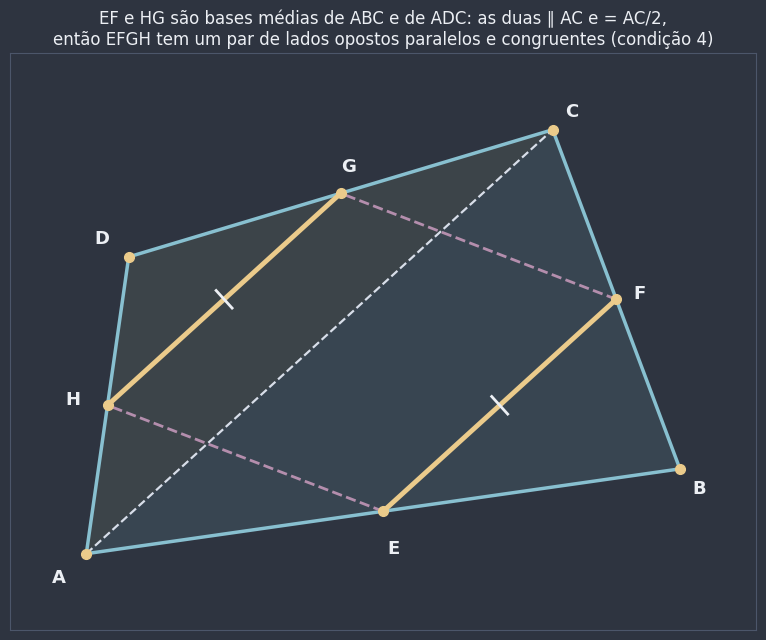

In [7]:
fig, ax = plt.subplots(figsize=(9, 6.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, quadrilatero_5, margem=0.9)
ax.add_patch(Polygon([A5, B5, C5], closed=True, facecolor=COR_PONTO, alpha=0.12, edgecolor="none"))
ax.add_patch(Polygon([A5, C5, D5], closed=True, facecolor=COR_DESTAQUE, alpha=0.12, edgecolor="none"))
for P, Q in ((A5, B5), (B5, C5), (C5, D5), (D5, A5)):
    ax.plot(*zip(P, Q), color=COR_PONTO, lw=2.5)
ax.plot(*zip(A5, C5), color=NORD_TEXTO_SEC, lw=1.6, linestyle="--")
ax.plot(*zip(E, F), color=COR_AVISO, lw=3.5)
ax.plot(*zip(H, G), color=COR_AVISO, lw=3.5)
ax.plot(*zip(F, G), color=COR_EXTRA, lw=2, linestyle="--")
ax.plot(*zip(E, H), color=COR_EXTRA, lw=2, linestyle="--")
marcar_congruentes(ax, E, F, 1)
marcar_congruentes(ax, H, G, 1)
for P, nome, deslocamento in ((A5, "A", (-0.4, -0.35)), (B5, "B", (0.15, -0.3)), (C5, "C", (0.15, 0.15)),
                              (D5, "D", (-0.4, 0.15)), (E, "E", (0.05, -0.5)), (F, "F", (0.2, 0.0)),
                              (G, "G", (0.0, 0.25)), (H, "H", (-0.5, 0.0))):
    ax.plot(*P, "o", color=COR_AVISO, markersize=7, zorder=7)
    ax.text(P[0] + deslocamento[0], P[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")
ax.set_title("EF e HG são bases médias de ABC e de ADC: as duas ∥ AC e = AC/2,\n"
             "então EFGH tem um par de lados opostos paralelos e congruentes (condição 4)",
             color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

**Exercício 6.** Quando o paralelogramo de Varignon é um retângulo? E um losango?

In [8]:
QUADRILATEROS_EX6 = {
    "pipa": [(0, 2), (2, 0), (6, 2), (2, 4)],
    "trapézio isósceles": [(0, 0), (6, 0), (4.5, 3), (1.5, 3)],
    "diagonais ≡ e ⊥": [(0, 2), (2, -1), (6, 2), (2, 5)],
    "qualquer": [(0, 0), (5, 1), (4, 4), (1, 3)],
}
QUADRILATEROS_EX6 = {nome: [np.array(v, dtype=float) for v in vertices] for nome, vertices in QUADRILATEROS_EX6.items()}

# (a) O nome mais específico do quadrilátero dos pontos médios.
nomes_varignon_ex6 = {nome: nome_mais_especifico(*pontos_medios_ex5(*vertices))
                      for nome, vertices in QUADRILATEROS_EX6.items()}


# (b) As diagonais do quadrilátero original.
def diagonais_do_original(A, B, C, D) -> tuple[bool, bool]:
    """(congruentes, perpendiculares) para as diagonais AC e BD."""
    congruentes = math.isclose(math.dist(A, C), math.dist(B, D))
    perpendiculares = math.isclose(float(np.dot(C - A, D - B)), 0, abs_tol=1e-9)
    return congruentes, perpendiculares


diagonais_ex6 = {nome: diagonais_do_original(*vertices) for nome, vertices in QUADRILATEROS_EX6.items()}

# (c) Os lados de EFGH são paralelos às diagonais de ABCD (EF ∥ AC e FG ∥ BD). Então o ângulo entre
#     dois lados consecutivos de EFGH é o mesmo ângulo entre as diagonais: EFGH tem ângulo reto
#     exatamente quando AC ⊥ BD. E os lados de EFGH medem AC/2 e BD/2: são iguais exatamente
#     quando AC = BD.
condicao_retangulo_ex6 = "diagonais perpendiculares"
condicao_losango_ex6 = "diagonais congruentes"

display(pd.DataFrame([
    {"quadrilátero": nome, "diagonais ≡?": "✅" if diagonais_ex6[nome][0] else "❌",
     "diagonais ⊥?": "✅" if diagonais_ex6[nome][1] else "❌", "Varignon é": nomes_varignon_ex6[nome]}
    for nome in QUADRILATEROS_EX6
]).style.hide(axis="index"))
print(f"Varignon é retângulo  <=>  {condicao_retangulo_ex6}")
print(f"Varignon é losango    <=>  {condicao_losango_ex6}")
# Repare no "cruzamento" dos papéis: o que dá RETÂNGULO no Varignon (ângulo reto) vem de diagonais
# PERPENDICULARES no original, e o que dá LOSANGO (lados iguais) vem de diagonais CONGRUENTES.
# A pipa (diagonais ⊥) e o trapézio isósceles (diagonais ≡) são os exemplos típicos;
# com as duas coisas juntas, o Varignon é um quadrado.

quadrilátero,diagonais ≡?,diagonais ⊥?,Varignon é
pipa,❌,✅,retângulo
trapézio isósceles,✅,❌,losango
diagonais ≡ e ⊥,✅,✅,quadrado
qualquer,❌,❌,paralelogramo


Varignon é retângulo  <=>  diagonais perpendiculares
Varignon é losango    <=>  diagonais congruentes
